## 📑 Table of Contents

1. Data Overview
2. Data Cleaning
3. Top 10 Countries by Olympic Medals
4. Top 10 Athletes by Medals
5. Most Popular Olympic Sports
6. Gender Participation
7. Olympic Participation Trend
8. Conclusion

# 🥇 Olympic Data Analysis

## Project Overview

This project analyzes 120 years of Olympic history using Python. The analysis explores medal distribution, top-performing athletes, sports popularity, gender participation, and historical Olympic trends.

### Objectives
- Analyze medals won by different countries
- Identify the top Olympic athletes
- Explore the popularity of different sports
- Compare male and female participation
- Study participation trends over time

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Improve notebook appearance
plt.style.use("ggplot")
sns.set_theme()

# Show all columns
pd.set_option("display.max_columns", None)

In [14]:
athletes = pd.read_csv("../data/athlete_events.csv")
regions = pd.read_csv("../data/noc_regions.csv")

print("Athlete dataset shape:", athletes.shape)
print("Regions dataset shape:", regions.shape)

Athlete dataset shape: (271116, 15)
Regions dataset shape: (230, 3)


In [15]:
df = athletes.merge(regions, on="NOC", how="left")

df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


## 📋 Data Overview

Before performing any analysis, let's understand the structure of the dataset, identify missing values, and check for duplicate records.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
 15  region  270746 non-null  str    
 16  notes   5039 non-null    str    
dtypes: float64(3), int64(2), str(12)
memory usage: 35.2 MB


In [17]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [18]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64

In [19]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1385


## 🧹 Data Cleaning

To prepare the dataset for analysis:
- Remove duplicate records.
- Replace missing values in the `Medal` column with `"No Medal"` for easier analysis.

In [20]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Replace missing medal values
df["Medal"] = df["Medal"].fillna("No Medal")

# Check the new shape
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (269731, 17)


## 🏆 Top 10 Countries by Olympic Medals

This analysis identifies the countries that have won the highest number of Olympic medals throughout history.

In [21]:
# Filter only rows where a medal was won
medals = df[df["Medal"] != "No Medal"]

# Count medals by country
country_medals = (
    medals.groupby("region")["Medal"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

country_medals

region
USA          5637
Russia       3947
Germany      3756
UK           2067
France       1767
Italy        1637
Sweden       1536
Canada       1352
Australia    1349
Hungary      1135
Name: Medal, dtype: int64

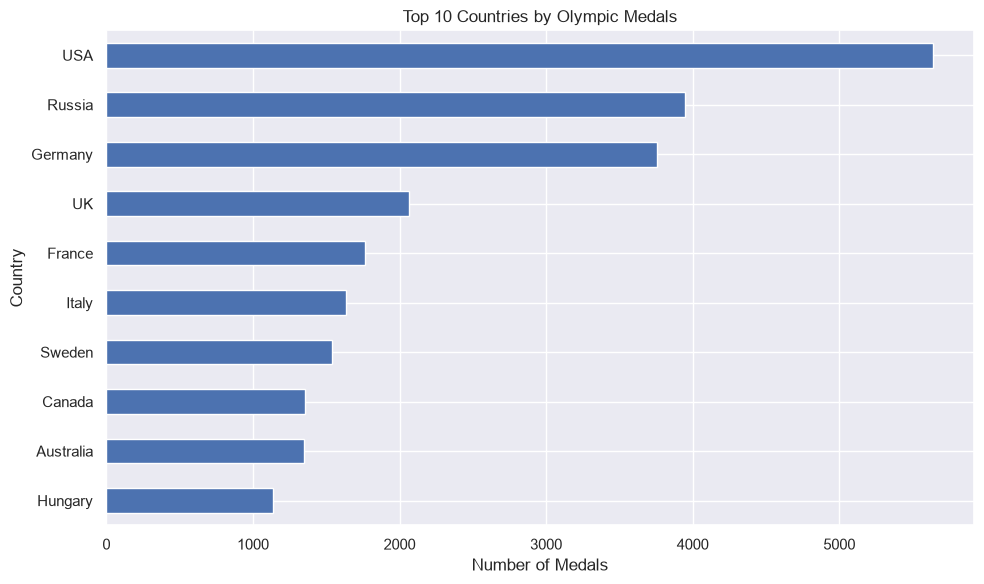

In [22]:
plt.figure(figsize=(10,6))

country_medals.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Olympic Medals")
plt.xlabel("Number of Medals")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

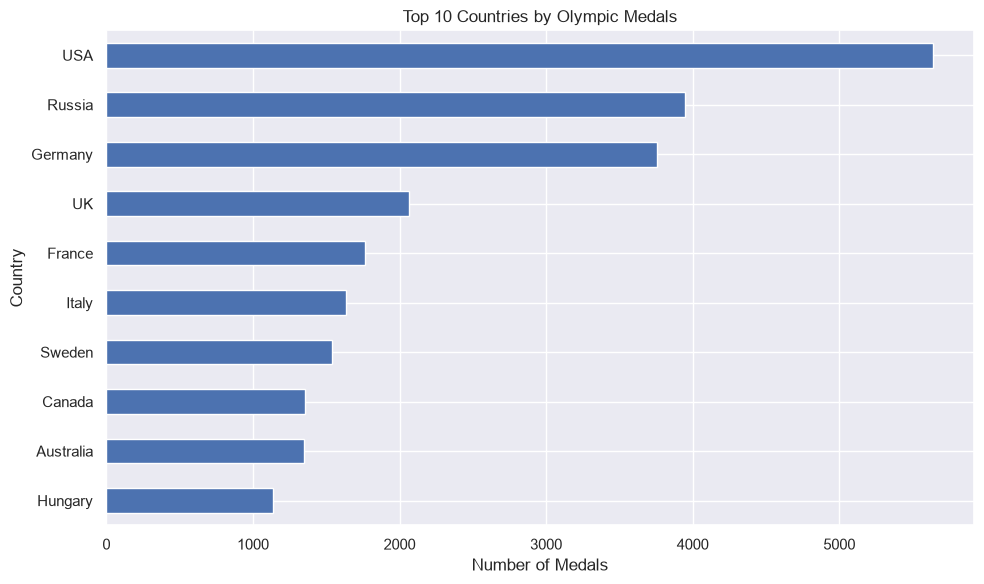

In [23]:
plt.figure(figsize=(10,6))

country_medals.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Olympic Medals")
plt.xlabel("Number of Medals")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("../images/top_10_countries_medals.png")

plt.show()

## 🥇 Top 10 Athletes by Olympic Medals

This analysis identifies the athletes who have won the highest number of Olympic medals.

In [ ]:
top_athletes = (
    medals.groupby("Name")["Medal"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_athletes

In [ ]:
plt.figure(figsize=(10,6))

top_athletes.sort_values().plot(kind="barh")

plt.title("Top 10 Athletes by Olympic Medals")
plt.xlabel("Number of Medals")
plt.ylabel("Athlete")

plt.tight_layout()

plt.savefig("../images/top_10_athletes.png")

plt.show()

### Key Insights

- A small group of athletes has won an exceptionally high number of Olympic medals.
- These athletes maintained outstanding performance across multiple Olympic Games.
- Success often comes from competing in events with multiple medal opportunities.

## 🏀 Most Popular Olympic Sports

This analysis identifies the sports with the highest number of athlete participations in Olympic history.

In [ ]:
popular_sports = (
    df["Sport"]
    .value_counts()
    .head(10)
)

popular_sports

In [ ]:
plt.figure(figsize=(10,6))

popular_sports.sort_values().plot(kind="barh")

plt.title("Top 10 Most Popular Olympic Sports")
plt.xlabel("Number of Participations")
plt.ylabel("Sport")

plt.tight_layout()

plt.savefig("../images/top_10_sports.png")

plt.show()

### Key Insights

- Athletics has the highest number of athlete participations.
- Swimming and Gymnastics are among the most represented sports.
- The popularity of a sport is reflected by the number of athletes participating across Olympic Games.